# **PREDICIÓN DE UN RESULTADO EN UN PARTIDO EN LA PREMIER LEAGUE 2024-25**-**DAVID FERNÁNDEZ MORENO-TAREA MÓDULO 4**

**EL PROBLEMA**

En el fútbol moderno, ser capaz de **predicir el resultado de un partido** antes de que comience, es especialmente relevante para:


*   **Análisis de rendimiento competitivo:** evaluar la probabilida de éxito de un equipo antes de un partido
*   **Planificación táctica**: ajustar estrategias en función del context del partido

*   **Scouting y analisis previo del rival:** identificar fortalezas y debilidades antes del entrenamiento


**DATA SET**

Utilizaremos el data set "Datos de partidos de la Premier League (2024-2025): Métricas avanzadas" de Kaggle, que contiene:




*   **Resultados** de la Premier League
*   **Temporada**: 2024-2025


*   **Variables**: 59 columnas de métricas avanzadas de los partidos







**VARIABLE OBJETIVO**

Predecir el resultado de un partido en base a sus variables más características:


*   **Gana**
*  **Empata**


*   **Pierde**

**METODOLOGÍA: CRISP-DM**

Seguiremos las 6 fases de la metodología Cross-Industry Stnadar Process for Data Mining:


1.   **Business Understanding**: Comprensión del problema deportivo

1.   **Data Understanding**: Análisis Exploratorio de Datos (EDA)


1.  **Data Preparation**: Limpieza y protección de datos
2.   **Modeling**: entrenamiento de modelos de clasificación


1.   **Evaluation**: evaluación y comparación de modelos



2.   **Deployment**: Persistencia del modelo final



**Modelos a Implementar**

Vamos a comparar 4 algoritmos clásicos de Machine Learning:



1.  **Regresión Logística**
2.   **K-Nearest Neighbors (KNN)**


1.   **Árboles de Decisión**
2.   Random Forest
**texto en negrita**




# **FASE 1. BUSINESS UNDERSTANDING**


**¿Podemos predecir el resultado de un partido basándonos únicamente en las características de los partidos en una temporada entrera?**

**Objetivo Deportivo**

Desarrollar un sistema que permite predecir el resultado de un partido antes de que comience, analizando las características de los partidos previamente disputados.

**Objetivo técnico**

Construir y comparar 4 modelos de clasificación supervisada, evaluando cual ofrece mejor rendimiento predictivo y interpretabilidad.

**Criterios de éxito**



1.   **Accuracy mínimo**: >75% en conjunto de prueba

1.   **Balance entre clases**: Precisión y Recall equilibrados
2.   **Interpretabilidad:** Entender que características definen cada partido


2.   **Generalización**: modelo que funcione en diferentes ligas



**Restricciones**

Dado que el objetivo es predecir el resultado antes del partido, se excluiran las variables que se generan durante el encuentro y que no estarían disponibles en un esencario real de predicción. Estas variables son:


*   Score

*   Yellow_cards

*   Red_cards

*   Offsides

*   Opp_score
*   opp_shots


*  corners


*  shots


*   shots_on_target


*   fouls

*   possession_pct





# **FASE 2. DATA UNDERSTANDING**

IMPORTACIÓN DE LIBRERÍAS

In [ ]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Scikit-learn: Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Scikit-learn: Modelos de Clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# Scikit-learn: Métricas y Evaluación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)

# Para manejo de desbalanceo de clases
from sklearn.utils.class_weight import compute_class_weight

# Para guardar modelos
import joblib
import json

# Sistema y rutas
import os


CARGA DE DATOS

In [ ]:
df=pd.read_csv ("/content/drive/MyDrive/Python/Master en IA/Móulo 4/premier_league_2024_25_season_games.csv")

INSPECCIÓN INICIAL DEL DATASET

In [ ]:
df.shape

(760, 59)

In [ ]:
df.head()

,won,game_id,date,season,venue,attendance,team_id,team_name,home_away,team_record,...,rolling_corners_10,rolling_offsides_10,opp_team_id,opp_score,opp_shots,opp_rest_days,opp_season_win_pct,opp_shot_conversion,is_home,rest_advantage
0,1,704282,2024-08-17 14:00:00+00:00,2025,Goodison Park,39217.0,331,Brighton & Hove Albion,away,1-0-0,...,NaN,NaN,368,0,0.0,4.0,0.450000,0.1,0,0.0
1,1,704291,2024-08-24 11:30:00+00:00,2025,American Express Stadium,31537.0,331,Brighton & Hove Albion,home,2-0-0,...,5.000000,1.000000,360,1,0.0,7.0,65.000000,0.1,1,-1.0
2,0,704299,2024-08-31 11:30:00+00:00,2025,Emirates Stadium,60326.0,331,Brighton & Hove Albion,away,2-1-0,...,4.500000,0.500000,359,1,0.0,6.0,23.500000,0.1,0,1.0
3,0,704311,2024-09-14 14:00:00+00:00,2025,American Express Stadium,41573.0,331,Brighton & Hove Albion,home,2-2-0,...,5.333333,0.666667,373,0,0.0,10.0,67.666667,0.1,1,0.0
4,0,704320,2024-09-22 13:00:00+00:00,2025,American Express Stadium,31444.0,331,Brighton & Hove Albion,home,2-3-0,...,6.250000,0.750000,393,2,0.0,7.0,65.500000,0.1,1,0.0


In [ ]:
df.columns

Index(['won', 'game_id', 'date', 'season', 'venue', 'attendance', 'team_id',
       'team_name', 'home_away', 'team_record', 'draw', 'score', 'shots',
       'shots_on_target', 'possession_pct', 'fouls', 'yellow_cards',
       'red_cards', 'corners', 'offsides', 'cum_wins', 'cum_games',
       'season_win_pct', 'rest_days', 'rolling_score_3', 'rolling_shots_3',
       'rolling_shots_on_target_3', 'rolling_possession_pct_3',
       'rolling_fouls_3', 'rolling_yellow_cards_3', 'rolling_red_cards_3',
       'rolling_corners_3', 'rolling_offsides_3', 'rolling_score_5',
       'rolling_shots_5', 'rolling_shots_on_target_5',
       'rolling_possession_pct_5', 'rolling_fouls_5', 'rolling_yellow_cards_5',
       'rolling_red_cards_5', 'rolling_corners_5', 'rolling_offsides_5',
       'rolling_score_10', 'rolling_shots_10', 'rolling_shots_on_target_10',
       'rolling_possession_pct_10', 'rolling_fouls_10',
       'rolling_yellow_cards_10', 'rolling_red_cards_10', 'rolling_corners_10',
       

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Data columns (total 59 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   won                         760 non-null    int64  
 1   game_id                     760 non-null    int64  
 2   date                        760 non-null    object 
 3   season                      760 non-null    int64  
 4   venue                       760 non-null    object 
 5   attendance                  760 non-null    float64
 6   team_id                     760 non-null    int64  
 7   team_name                   760 non-null    object 
 8   home_away                   760 non-null    object 
 9   team_record                 760 non-null    object 
 10  draw                        760 non-null    int64  
 11  score                       760 non-null    int64  
 12  shots                       760 non-null    float64
 13  shots_on_target             760 non

In [ ]:
df.describe()

,won,game_id,season,attendance,team_id,draw,score,shots,shots_on_target,possession_pct,...,rolling_corners_10,rolling_offsides_10,opp_team_id,opp_score,opp_shots,opp_rest_days,opp_season_win_pct,opp_shot_conversion,is_home,rest_advantage
count,760.000000,760.000000,760.0,760.000000,760.000000,760.000000,760.000000,760.0,760.000000,760.000000,...,740.000000,740.000000,760.000000,760.000000,760.0,760.000000,760.000000,7.600000e+02,760.000000,760.000000
mean,0.377632,704468.500000,2025.0,40414.884211,366.250000,0.244737,1.460526,0.0,4.456579,49.061784,...,5.077361,1.674275,366.250000,1.460526,0.0,6.477632,16.050986,1.000000e-01,0.500000,0.000000
std,0.485114,109.768411,0.0,16582.668204,14.627681,0.430214,1.211939,0.0,2.438862,12.987148,...,1.574346,0.612228,14.627681,1.211939,0.0,2.328610,29.670247,5.554771e-17,0.500329,1.374528
min,0.000000,704279.000000,2025.0,11129.000000,331.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,331.000000,0.000000,0.0,2.000000,0.300000,1.000000e-01,0.000000,-8.000000
25%,0.000000,704373.750000,2025.0,29856.750000,360.750000,0.000000,1.000000,0.0,3.000000,41.475000,...,4.000000,1.300000,360.750000,1.000000,0.0,5.000000,3.814076,1.000000e-01,0.000000,-1.000000
50%,0.000000,704468.500000,2025.0,38316.000000,367.500000,0.000000,1.000000,0.0,4.000000,49.700000,...,4.900000,1.600000,367.500000,1.000000,0.0,7.000000,7.642401,1.000000e-01,0.500000,0.000000
75%,1.000000,704563.250000,2025.0,54790.000000,375.250000,0.000000,2.000000,0.0,6.000000,57.725000,...,6.000000,2.000000,375.250000,2.000000,0.0,8.000000,14.640625,1.000000e-01,1.000000,1.000000
max,1.000000,704658.000000,2025.0,73839.000000,393.000000,1.000000,5.000000,0.0,12.000000,75.082000,...,13.000000,6.000000,393.000000,5.000000,0.0,10.000000,260.000000,1.000000e-01,1.000000,8.000000


In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
rolling_shots_3,20
rolling_score_3,20
rolling_shots_on_target_3,20
rolling_offsides_10,20
rolling_corners_10,20
rolling_red_cards_10,20
rolling_yellow_cards_10,20
rolling_fouls_10,20
rolling_possession_pct_10,20
rolling_shots_on_target_10,20


**ANÁLISIS DE LA VARIABLE OBJETIVO**

Se realizó a partir de las variables "won" y "draw", que indican si el equipo ganó empató el partido, respectivamente. A partir de ellas se construyo una variable categórica denominada "result", con tres posibles valores: victoria, empate y derrota.


In [ ]:
df ["won"].value_counts()

,count
won,
0,473
1,287


In [ ]:
df ["draw"].value_counts ()

,count
draw,
0,574
1,186


In [ ]:
def get_result (row):
  if row ["won"]==1:
    return "win"
  elif row ["draw"]==1:
    return "draw"
  else:
    return "loss"

In [ ]:
df["result"]= df.apply (get_result, axis=1)


In [ ]:
df [["won", "draw", "result"]].head(10)

,won,draw,result
0,1,0,win
1,1,0,win
2,0,1,draw
3,0,1,draw
4,0,1,draw
5,0,0,loss
6,1,0,win
7,1,0,win
8,0,1,draw
9,0,0,loss


In [ ]:
df ["result"].value_counts ()

,count
result,
win,287
loss,287
draw,186


In [ ]:
df ["result"]. value_counts (normalize= True)

,proportion
result,
win,0.377632
loss,0.377632
draw,0.244737


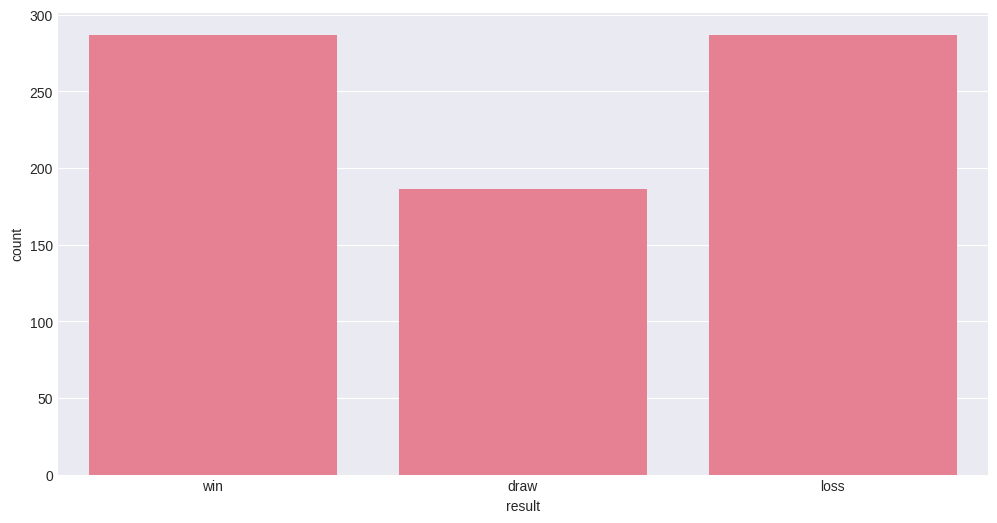

In [ ]:
sns.countplot (x="result", data=df)
plt.show ()

**ANÁLISIS EXPLORATORIO DE DATOS (EDA)**

Analizaremos las distribuciones de las métricas numéricas más relevantes para comprender como se comportan los equipos antes del partido y cómo pueden influir en el resultado final.

Este análisis permite:


*  Entender la variabilidad de las variables

*  Detectar valores atípicos
*  Identificar diferencias de escala


*   Anticiparsde a posibles transformaciones necesarias para el modelado




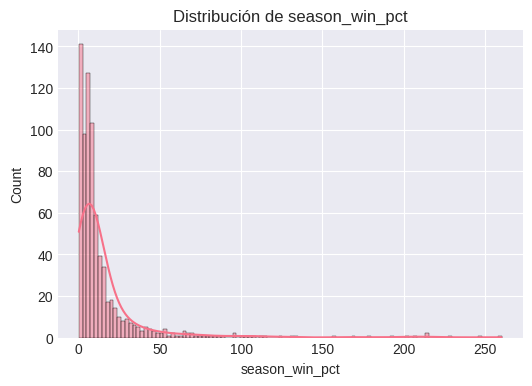

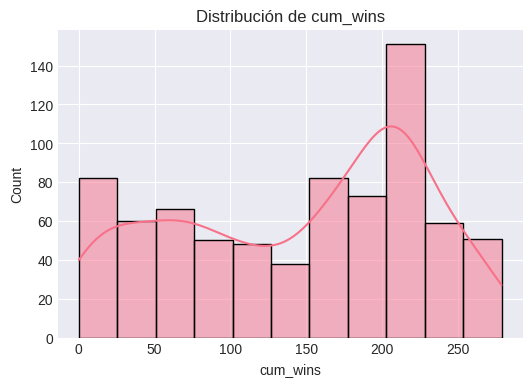

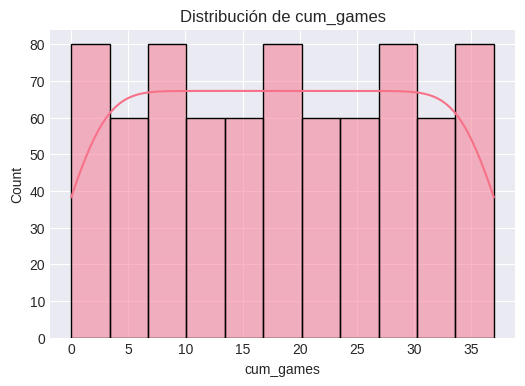

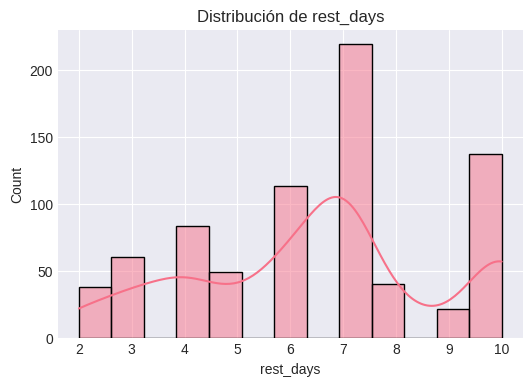

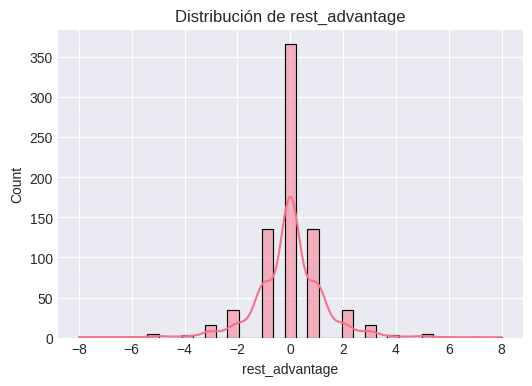

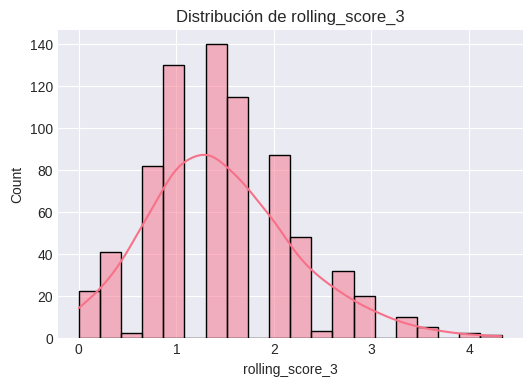

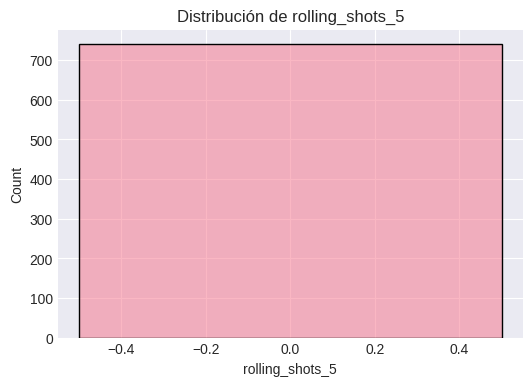

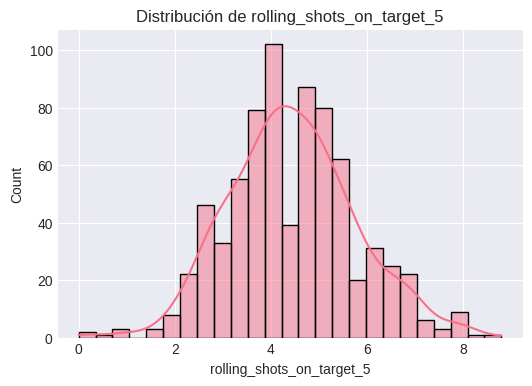

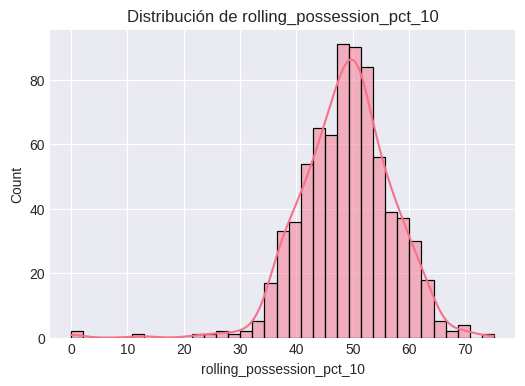

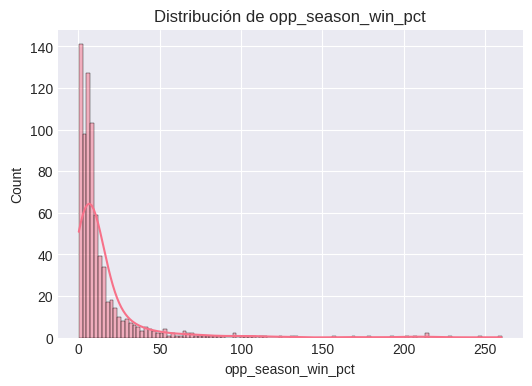

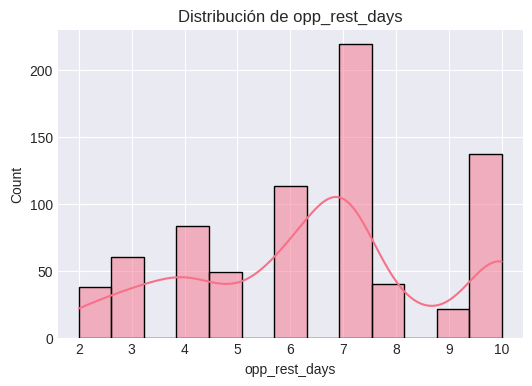

In [ ]:
variables_eda= [ 'season_win_pct',
    'cum_wins',
    'cum_games',
    'rest_days',
    'rest_advantage',
    'rolling_score_3',
    'rolling_shots_5',
    'rolling_shots_on_target_5',
    'rolling_possession_pct_10',
    'opp_season_win_pct',
    'opp_rest_days'
]

for col in variables_eda:
  plt.figure (figsize =(6,4))
  sns.histplot (df [col], kde=True)
  plt.title (f"Distribución de {col}")
  plt.show ()

**ANALISIS POR RESULTADO: COMPARACIÓN DE ESTADÍSTICAS CLAVE**

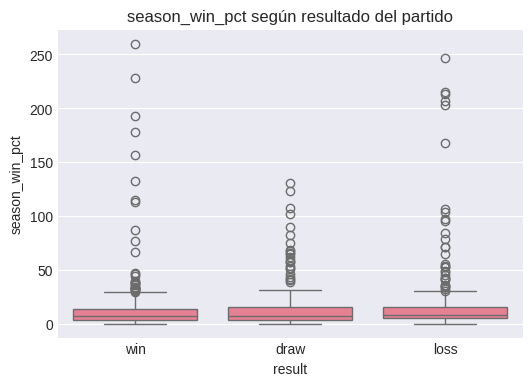

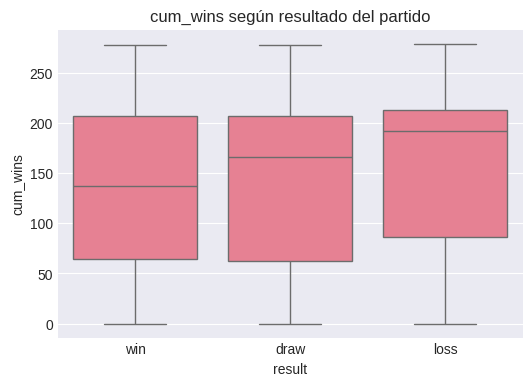

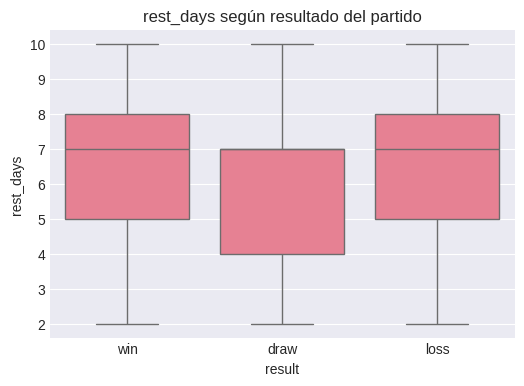

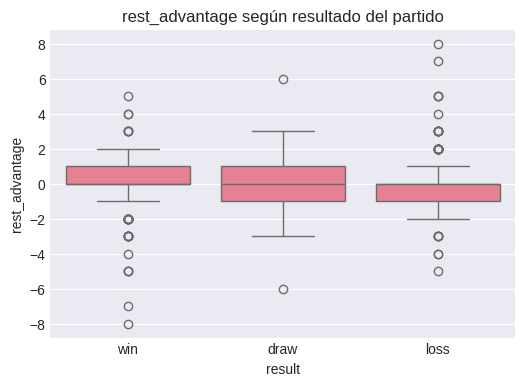

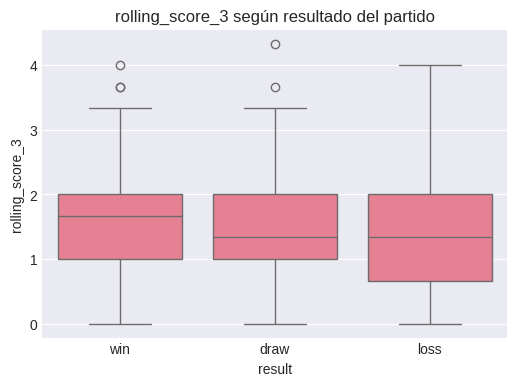

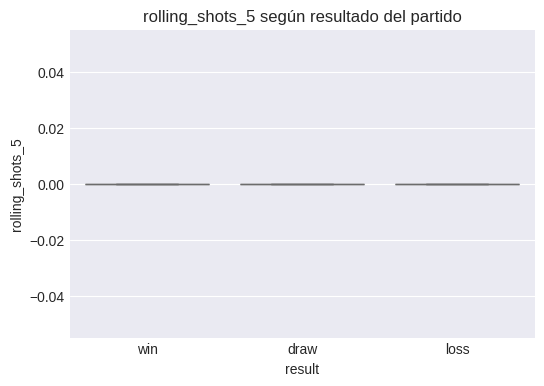

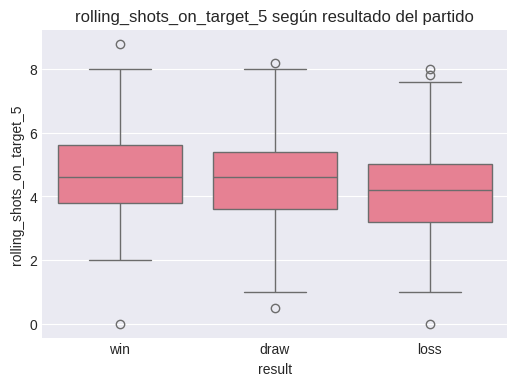

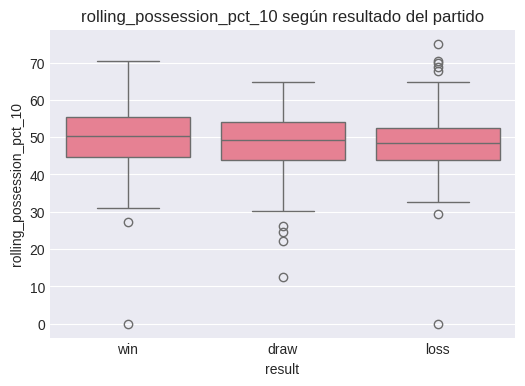

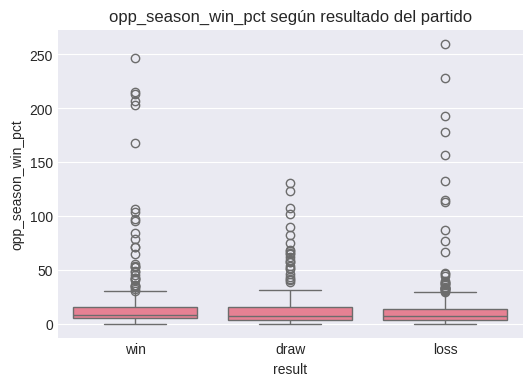

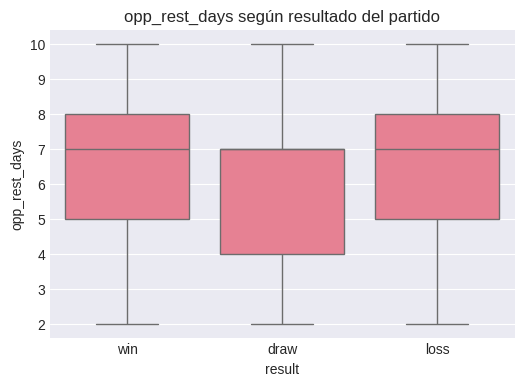

In [ ]:
variables_eda =[    'season_win_pct',
    'cum_wins',
    'rest_days',
    'rest_advantage',
    'rolling_score_3',
    'rolling_shots_5',
    'rolling_shots_on_target_5',
    'rolling_possession_pct_10',
    'opp_season_win_pct',
    'opp_rest_days'
]
for col in variables_eda:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='result', y=col, data=df)
    plt.title(f'{col} según resultado del partido')
    plt.show()

Observaciones

El analisis comparativo de las variables numéricas según el restulstado del partod muestra que los equipos que ganan suelen presentar mejores valroes en métricas de rendimiento acumuluado y forma reciente, como season_win_pct o las estadístias rolling. Por el contrario, los equipos que pierden tienden a registrar varoales más bajos en estas variables, mientras que los empates se situán generalmente en posiciones intermedias


**MATRIZ DE CORRELACIÓN**



1.   Identificar relaciones entre variables numéricas

1.   Detectar variables redundantes
2.   Observar que variables pueden estar más asociadas al resultado


2.   Anticipar problemas de multicolinealidad




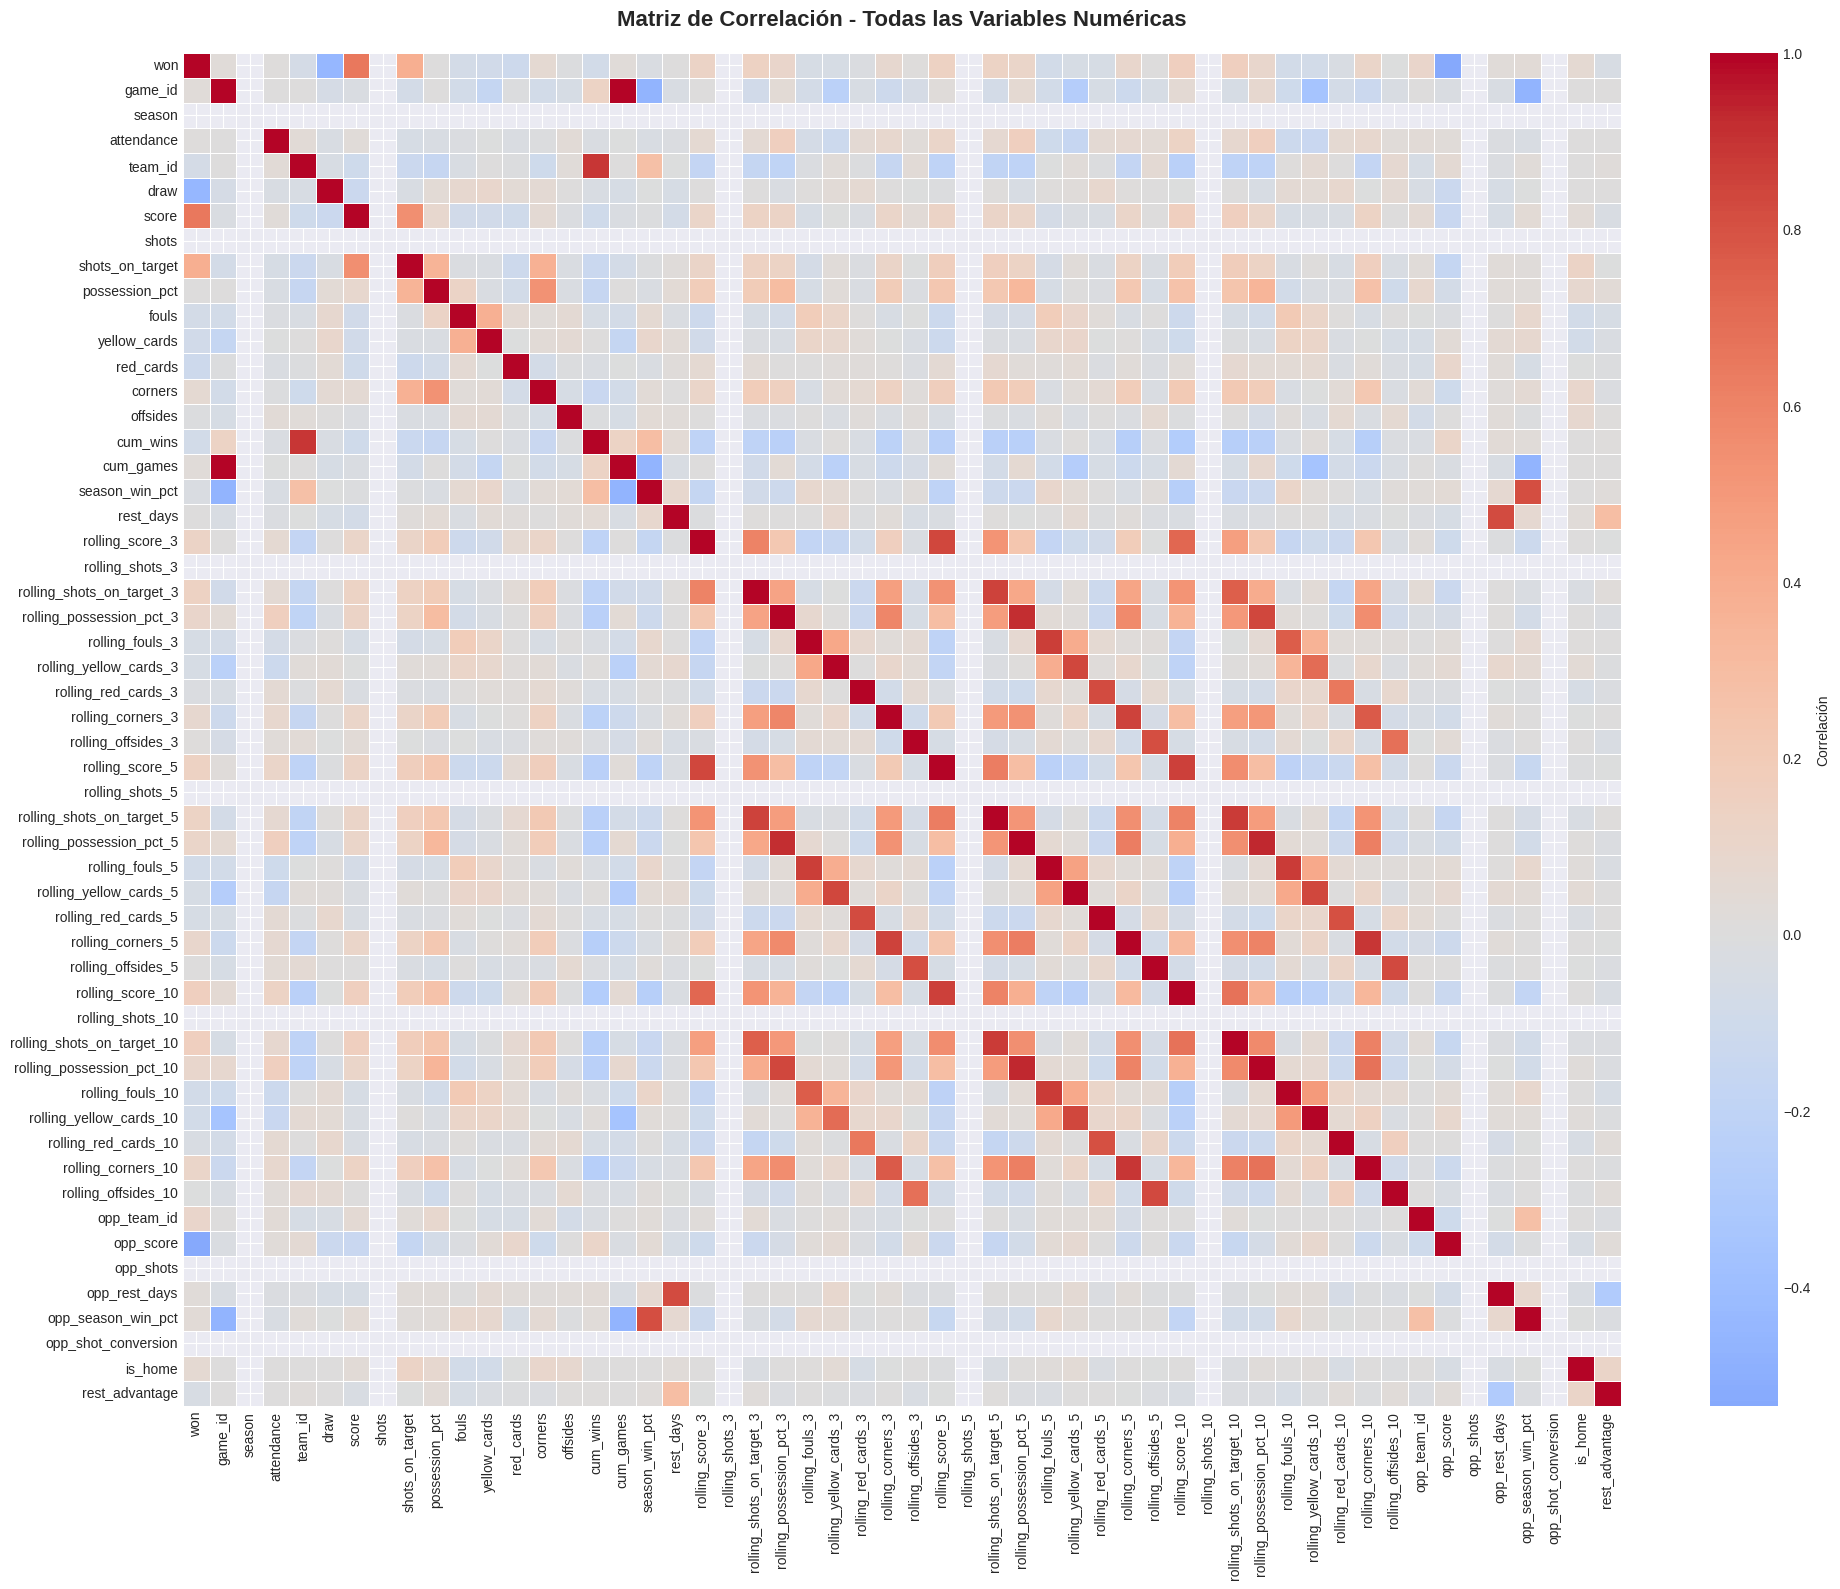

CORRELACIONES MUY FUERTES (|r| > 0.9)


,Variable 1,Variable 2,Correlación
0,game_id,cum_games,0.998404
2,rolling_possession_pct_5,rolling_possession_pct_10,0.930927
1,rolling_possession_pct_3,rolling_possession_pct_5,0.910686



⚠️  MULTICOLINEALIDAD DETECTADA:
   Variables altamente correlacionadas pueden causar redundancia
   Consideraremos eliminar algunas en la fase de preparación


In [ ]:
# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calcular matriz de correlación
corr_matrix = df[numeric_cols].corr()

# Visualizar matriz de correlación
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'label': 'Correlación'})
plt.title('Matriz de Correlación - Todas las Variables Numéricas',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Correlaciones más fuertes (> 0.9)
print("=" * 80)
print("CORRELACIONES MUY FUERTES (|r| > 0.9)")
print("=" * 80)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'Variable 1': corr_matrix.columns[i],
                'Variable 2': corr_matrix.columns[j],
                'Correlación': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlación', ascending=False)
    display(high_corr_df)
    print("\n⚠️  MULTICOLINEALIDAD DETECTADA:")
    print("   Variables altamente correlacionadas pueden causar redundancia")
    print("   Consideraremos eliminar algunas en la fase de preparación")
else:
    print("✅ No se detectaron correlaciones extremadamente altas")

# **FASE 3. DATA PREPARATION**

LIMPIEZA Y TRANSFORMACIÓN DE DATOS

In [ ]:
df [(df["won"]== 1)& (df ["draw"]==1)].shape

(0, 60)

In [ ]:
def get_result(row):
    if row['won'] == 1:
        return 'win'
    elif row['draw'] == 1:
        return 'draw'
    else:
        return 'loss'

df['result'] = df.apply(get_result, axis=1)
df['result'].value_counts()


,count
result,
win,287
loss,287
draw,186


In [ ]:
cols_to_drop = [
    # Identificadores / texto / metadata
    'game_id', 'team_id', 'opp_team_id', 'team_name', 'venue', 'home_away', 'team_record', 'date',

    # Variables objetivo auxiliares
    'won', 'draw',

    # Variables del partido actual (leakage)
    'score', 'shots', 'shots_on_target', 'possession_pct', 'fouls',
    'yellow_cards', 'red_cards', 'corners', 'offsides',
    'opp_score', 'opp_shots'
]

df_model = df.drop(columns=[c for c in cols_to_drop if c in df.columns]).copy()
df_model.shape
X = df_model.drop(columns=['result'])
y = df_model['result']

X.shape, y.shape


((760, 38), (760,))

Observaciones

Tras la selección de variables relevantes y la eliminación de aquellas que introducían data leakage o no aportaban valor predictivo, se obtuvo un dataset compuesto por 760 observaciones y 38 variables predictoras.

La variable objetivo contiene el reusltado del partido asociado a cada registro, lo que permite planear el problema como una tarea de clasificación supervisada.


MANEJO DE VALORES NULOS

In [ ]:
X.isna().sum().sort_values (ascending=False)


,0
rolling_yellow_cards_3,20
rolling_fouls_3,20
rolling_possession_pct_3,20
rolling_shots_on_target_3,20
rolling_shots_3,20
rolling_score_3,20
rolling_corners_5,20
rolling_offsides_5,20
rolling_score_10,20
rolling_shots_10,20


In [ ]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer (strategy= "median")
X_imputed=imputer.fit_transform (X)

In [ ]:
X_imputed=pd.DataFrame (X_imputed, columns=X.columns, index =X.index)
X_imputed.isna().sum().sum()

np.int64(0)

DVISIÓN DE DATOS: TRAIN/TEST



*   **TRAIN (80%)**: Para entrenar el modelo

*   **TEST (20%)**: Para evaluar el rendimiento en datos nunca vistos

*   **Stratify**: Mantener la proporción de clases en ambos conjuntos (importante con desbalanceo)



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test =train_test_split(
    X_imputed,
    y,
    test_size =0.2,
    stratify=y,
    random_state=42
)

In [ ]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)


,proportion
result,
loss,0.381579
win,0.375000
draw,0.243421


OBSERVACIONES

La división estratificada del dataset permitió mantener una proporción equilibrada de las clases del resultado del partido en los conjuntos de entrenamiento y prueba. Esto grantiza que el modelo se entrene y evalué bajo condiciones representativas, evitando sesgos derivados del desbalanceo de clases

ESTADARIZACIÓN DE FEATURES

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()
scaler.fit (X_train)

StandardScaler()

In [ ]:
X_train_scaled=scaler.transform (X_train)
X_test_scaled=scaler.transform (X_test)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

X_train_scaled_df.head()
print("ANTES")
print(X_train.describe())

print("\nDESPUÉS")
print(X_train_scaled_df.describe())


ANTES
       season    attendance    cum_wins   cum_games  season_win_pct  \
count   608.0    608.000000  608.000000  608.000000      608.000000   
mean   2025.0  40599.697368  141.972039   18.488487       15.630929   
std       0.0  16855.328317   81.789807   10.958655       29.696244   
min    2025.0  11129.000000    0.000000    0.000000        0.300000   
25%    2025.0  29765.250000   67.000000    9.000000        3.741925   
50%    2025.0  38773.500000  164.000000   18.000000        7.403866   
75%    2025.0  60122.500000  211.000000   28.000000       13.916667   
max    2025.0  73839.000000  278.000000   37.000000      260.000000   

        rest_days  rolling_score_3  rolling_shots_3  \
count  608.000000       608.000000            608.0   
mean     6.483553         1.444901              0.0   
std      2.323094         0.733865              0.0   
min      2.000000         0.000000              0.0   
25%      5.000000         1.000000              0.0   
50%      7.000000       

# **FASE 4. MODELING**


Entenaremos y compararemos 4 algoritmos diferentes, cada uno con sus fortalezas:



1.   **Regresión Logística**
2.   **K-Nearest Neighbors (KNN)**


1.   **Árboles de Decisión**
2.   **Random Forest**





1-REGRESIÓN LOGÍSTICA

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

2-KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=15)

knn.fit(X_train_scaled, y_train)


KNeighborsClassifier(n_neighbors=15)

3-Árbol de Decisión

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    max_depth=6,
    min_samples_leaf=10
)

tree.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                       min_samples_leaf=10, random_state=42)

4-Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=400, n_jobs=-1,
                       random_state=42)

COMPARACIÓN ENTRE LOS DIFERENTES MODELOS

In [ ]:
feature_cols = X_train.columns.tolist()


In [ ]:
import numpy as np
import pandas as pd

avg_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importancia_Promedio": np.abs(log_reg.coef_).mean(axis=0)  # promedio entre clases
}).sort_values("Importancia_Promedio", ascending=False)

avg_importance.head(10)


,Feature,Importancia_Promedio
15,rolling_score_5,0.304405
19,rolling_fouls_5,0.290661
18,rolling_possession_pct_5,0.278280
24,rolling_score_10,0.257770
27,rolling_possession_pct_10,0.241242
17,rolling_shots_on_target_5,0.215116
28,rolling_fouls_10,0.197258
34,opp_season_win_pct,0.191604
32,rolling_offsides_10,0.189853
26,rolling_shots_on_target_10,0.164782


In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    knn,
    X_test_scaled,
    y_test,
    n_repeats=15,
    random_state=42,
    scoring="f1_weighted"
)

perm_importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importancia": perm.importances_mean
}).sort_values("Importancia", ascending=False)

perm_importance_df.head(10)


,Feature,Importancia
5,rest_days,0.045961
33,opp_rest_days,0.038043
15,rolling_score_5,0.038007
2,cum_wins,0.034505
8,rolling_shots_on_target_3,0.033540
32,rolling_offsides_10,0.033067
36,is_home,0.031288
27,rolling_possession_pct_10,0.030215
4,season_win_pct,0.029781
20,rolling_yellow_cards_5,0.028283


In [ ]:
feature_importance_dt = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": tree.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance_dt.head(10)


,Feature,Importance
4,season_win_pct,0.139915
26,rolling_shots_on_target_10,0.139317
2,cum_wins,0.079595
1,attendance,0.076606
32,rolling_offsides_10,0.075402
34,opp_season_win_pct,0.072660
29,rolling_yellow_cards_10,0.055139
11,rolling_yellow_cards_3,0.048378
27,rolling_possession_pct_10,0.047885
8,rolling_shots_on_target_3,0.047236


In [ ]:
feature_importance_rf = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance_rf.head(10)


,Feature,Importance
1,attendance,0.061064
34,opp_season_win_pct,0.043867
2,cum_wins,0.041994
4,season_win_pct,0.040548
32,rolling_offsides_10,0.039869
9,rolling_possession_pct_3,0.039467
18,rolling_possession_pct_5,0.038407
27,rolling_possession_pct_10,0.037652
26,rolling_shots_on_target_10,0.036781
31,rolling_corners_10,0.036517


In [ ]:
models_comparison = {
    "Regresión Logística": avg_importance.head(5).set_index("Feature")["Importancia_Promedio"],
    "KNN (Permutation)": perm_importance_df.head(5).set_index("Feature")["Importancia"],
    "Árbol de Decisión": feature_importance_dt.head(5).set_index("Feature")["Importance"],
    "Random Forest": feature_importance_rf.head(5).set_index("Feature")["Importance"],
}


all_top_features = set()
for s in models_comparison.values():
    all_top_features.update(s.index)

comparison_matrix = []
for feature in all_top_features:
    row = {"Feature": feature}
    for model_name, importances in models_comparison.items():
        row[model_name] = float(importances.get(feature, 0))
    comparison_matrix.append(row)

comparison_df = pd.DataFrame(comparison_matrix).sort_values("Random Forest", ascending=False)
comparison_df


,Feature,Regresión Logística,KNN (Permutation),Árbol de Decisión,Random Forest
9,attendance,0.000000,0.000000,0.076606,0.061064
0,opp_season_win_pct,0.000000,0.000000,0.000000,0.043867
11,cum_wins,0.000000,0.034505,0.079595,0.041994
6,season_win_pct,0.000000,0.000000,0.139915,0.040548
2,rolling_offsides_10,0.000000,0.000000,0.075402,0.039869
1,rolling_score_5,0.304405,0.038007,0.000000,0.000000
5,rolling_score_10,0.257770,0.000000,0.000000,0.000000
4,opp_rest_days,0.000000,0.038043,0.000000,0.000000
3,rest_days,0.000000,0.045961,0.000000,0.000000
7,rolling_fouls_5,0.290661,0.000000,0.000000,0.000000


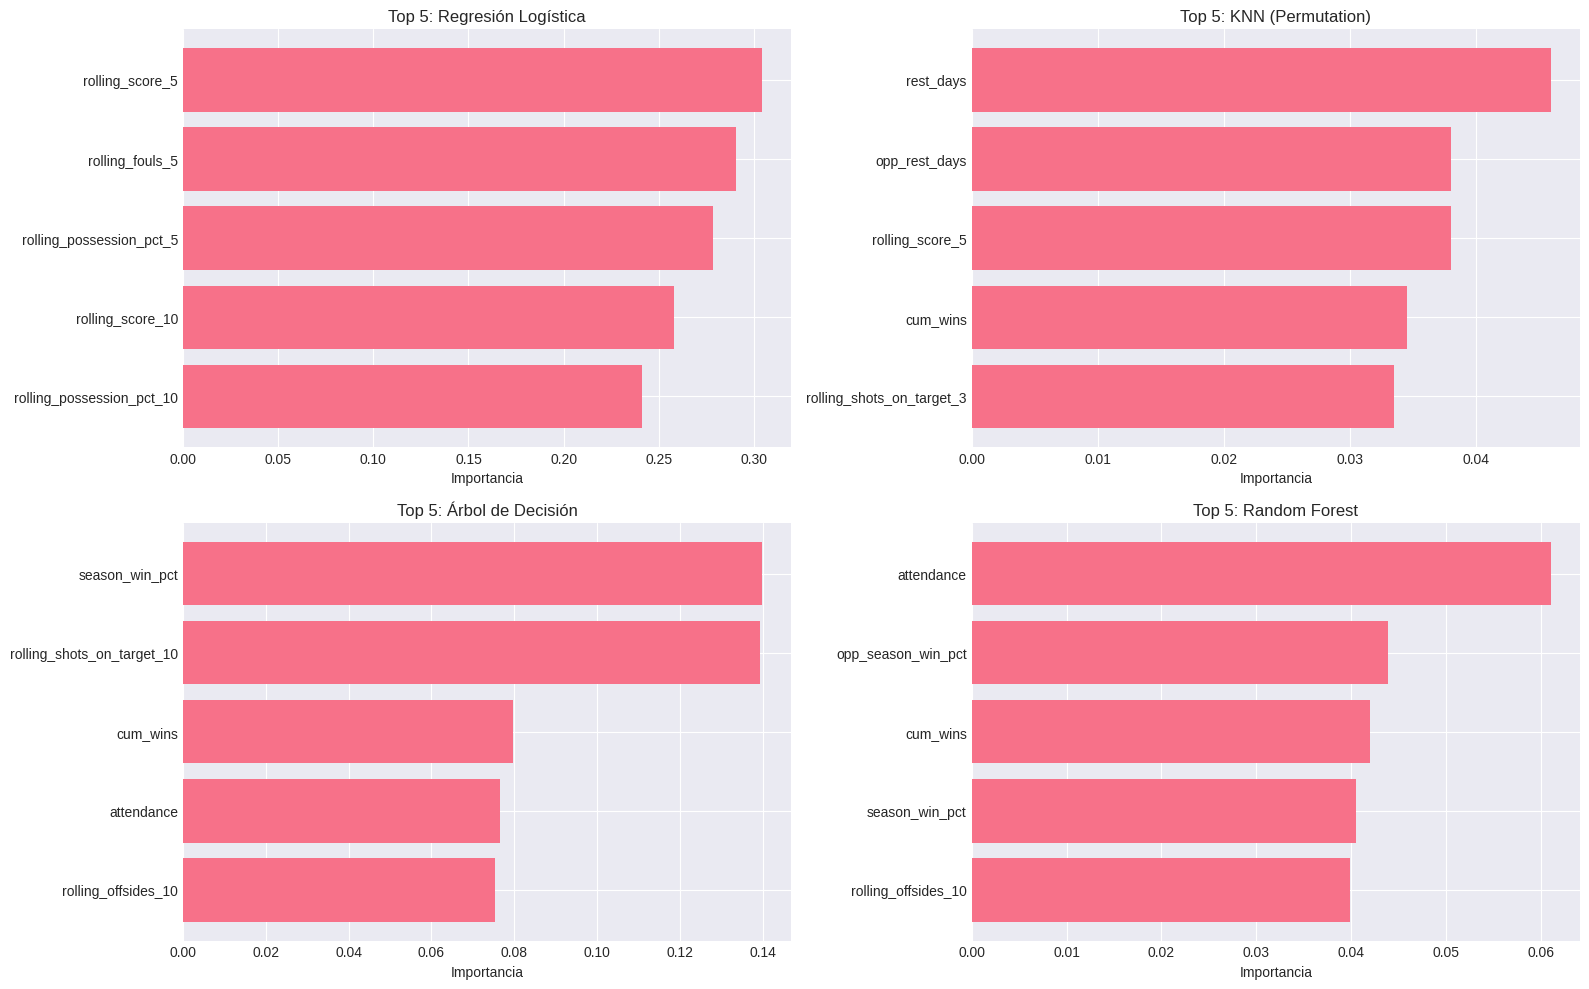

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (model_name, importances) in zip(axes, models_comparison.items()):
    ax.barh(importances.index, importances.values)
    ax.set_title(f"Top 5: {model_name}")
    ax.invert_yaxis()
    ax.set_xlabel("Importancia")

plt.tight_layout()
plt.show()


OBSERVACIONES

La comparación entre modelos muestra que las variables relacionadas con el rendimiento previo del equipo, como el porcentaje de victorias, las victorias acumuladas y las métricas rolling, aparecen de forma consistente como factores relevantes. Esto refuerza su importancia en la predicción del resultado de los partidos. Además, algunas variables contextuales como la asistencia o el descanso también adquieren peso en ciertos algoritmos, reflejando la complejidad del fenómeno analizado y la existencia de múltiples factores que influyen en el rendimiento competitivo.

# **FASE 5. EVALUATION**

Comparación de Métricas de Rendimiento

Evaluaremos los modelos usando múltiples métricas:

- **Accuracy**
- **Precisión**
- **Recall (Sensibilidad)**
- **F1-Score**

Promediado: (métricas de cada clase)

- **Macro**: Promedio simple
- **Weighted**: promedio ponderado por frecuencia de clases

In [ ]:
y_pred_log_reg = log_reg.predict(X_test_scaled)
y_pred_knn     = knn.predict(X_test_scaled)

y_pred_dt      = tree.predict(X_test)
y_pred_rf      = rf.predict(X_test)


In [ ]:
models = {
    'Regresión Logística': {'model': log_reg, 'predictions': y_pred_log_reg},
    'K-Nearest Neighbors': {'model': knn, 'predictions': y_pred_knn},
    'Árbol de Decisión': {'model': tree, 'predictions': y_pred_dt},
    'Random Forest': {'model': rf, 'predictions': y_pred_rf}
}


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for model_name, model_info in models.items():
    y_pred = model_info['predictions']

    accuracy = accuracy_score(y_test, y_pred)

    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro    = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro        = f1_score(y_test, y_pred, average='macro', zero_division=0)

    precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall_weighted    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_weighted        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({
        'Modelo': model_name,
        'Accuracy': accuracy,
        'Precision (Macro)': precision_macro,
        'Recall (Macro)': recall_macro,
        'F1-Score (Macro)': f1_macro,
        'Precision (Weighted)': precision_weighted,
        'Recall (Weighted)': recall_weighted,
        'F1-Score (Weighted)': f1_weighted
    })

results_df = pd.DataFrame(results)
results_df


,Modelo,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
0,Regresión Logística,0.361842,0.355901,0.354393,0.353403,0.371555,0.361842,0.365139
1,K-Nearest Neighbors,0.434211,0.396825,0.401705,0.394171,0.415199,0.434211,0.420468
2,Árbol de Decisión,0.348684,0.336597,0.333818,0.323412,0.353680,0.348684,0.337771
3,Random Forest,0.447368,0.390462,0.406776,0.391274,0.414955,0.447368,0.425041


In [ ]:
results_df.style.highlight_max(
    axis=0,
    subset=[
        'Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)',
        'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)'
    ],
    color='lightgreen'
)


,Modelo,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
0,Regresión Logística,0.361842,0.355901,0.354393,0.353403,0.371555,0.361842,0.365139
1,K-Nearest Neighbors,0.434211,0.396825,0.401705,0.394171,0.415199,0.434211,0.420468
2,Árbol de Decisión,0.348684,0.336597,0.333818,0.323412,0.353680,0.348684,0.337771
3,Random Forest,0.447368,0.390462,0.406776,0.391274,0.414955,0.447368,0.425041


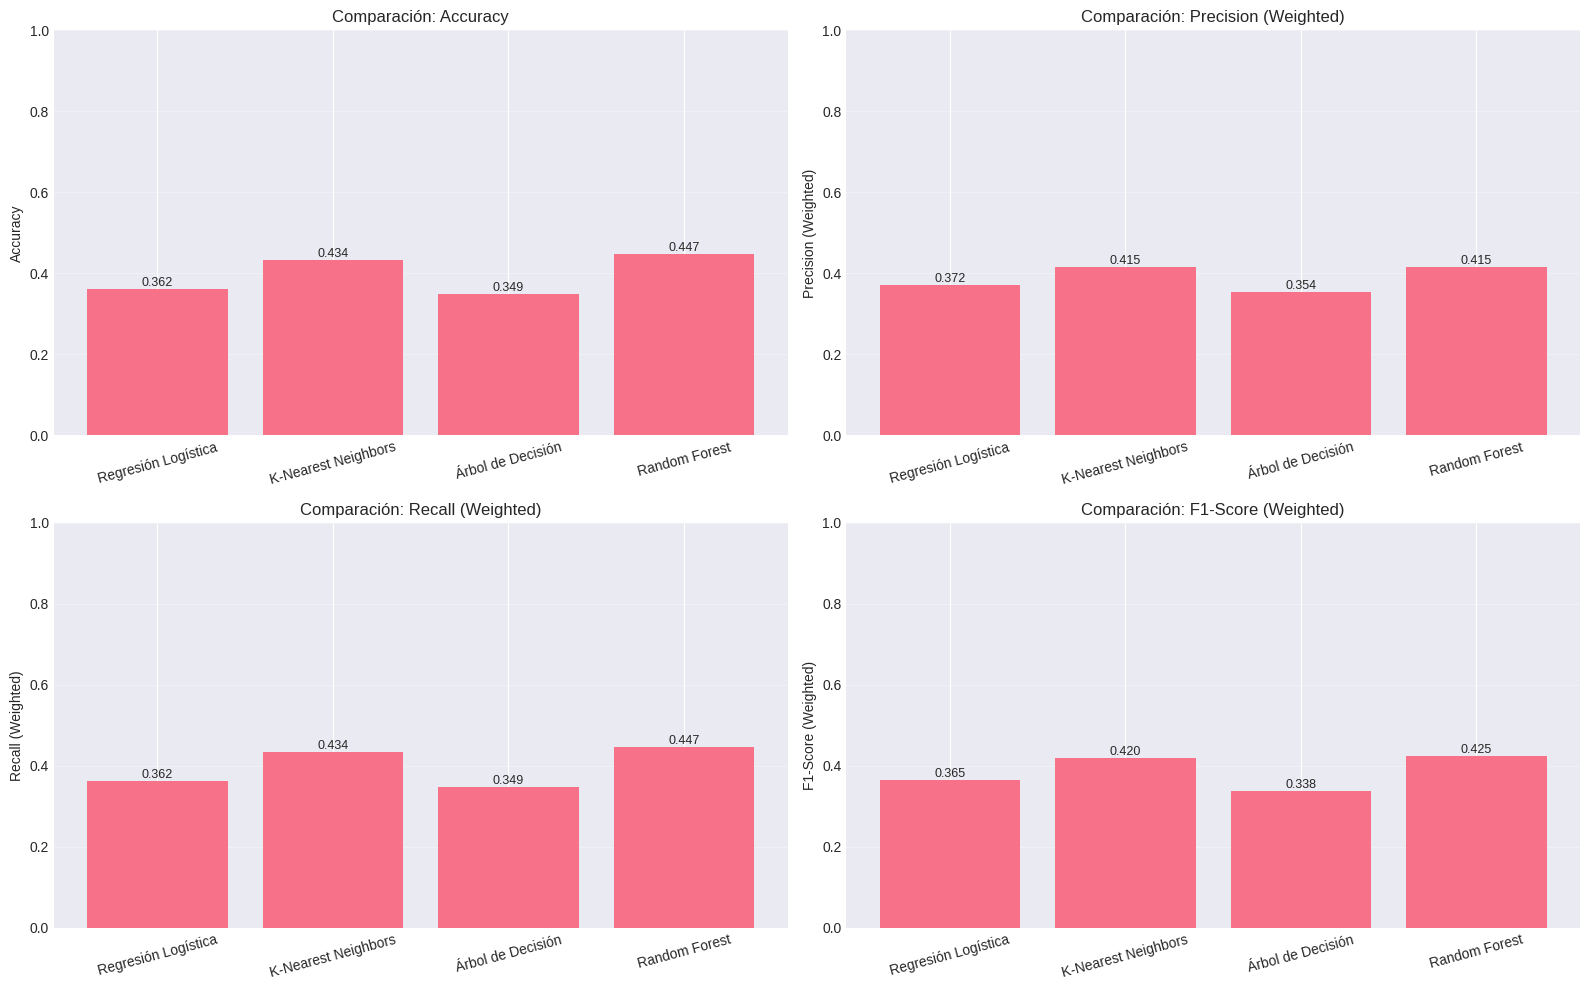

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics_to_plot = ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(results_df['Modelo'], results_df[metric])
    ax.set_ylabel(metric)
    ax.set_title(f'Comparación: {metric}')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
best_idx = results_df['F1-Score (Weighted)'].idxmax()
best_model_name = results_df.loc[best_idx, 'Modelo']
best_f1_score = results_df.loc[best_idx, 'F1-Score (Weighted)']
best_accuracy = results_df.loc[best_idx, 'Accuracy']

best_model_name, best_f1_score, best_accuracy


('Random Forest',
 np.float64(0.42504142870838296),
 np.float64(0.4473684210526316))

OBSERVACIONES

El modelo Random Forest presenta el mejor rendimiento según el F1-Score ponderado, por lo que se selcciona como modelo principal para la predicción del resultado de los partidos. Aunque los valores obtenidos no son elevados, resultan coherentes con la complejidad inherente al fútbol, donde intervienen múltiples factores dificiles de modelar y existe un algo grado de incertidumbre.

En este contecto, el modelo demuestra capacidad para identificar patrones relevantes en los datos pre-partido y ofrece un rendimiento superior al esperado por azar en un problema multiclase, lo que respalda su utilidad como herramienta de apoyo en la toma de decisiones deportivas

In [ ]:
for model_name, model_info in models.items():
    y_pred = model_info['predictions']

    print("=" * 80)
    print(f"REPORTE DE CLASIFICACIÓN: {model_name.upper()}")
    print("=" * 80)
    print(classification_report(y_test, y_pred, zero_division=0))
    print()

REPORTE DE CLASIFICACIÓN: REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

        draw       0.24      0.30      0.27        37
        loss       0.40      0.34      0.37        58
         win       0.43      0.42      0.42        57

    accuracy                           0.36       152
   macro avg       0.36      0.35      0.35       152
weighted avg       0.37      0.36      0.37       152


REPORTE DE CLASIFICACIÓN: K-NEAREST NEIGHBORS
              precision    recall  f1-score   support

        draw       0.26      0.16      0.20        37
        loss       0.47      0.55      0.51        58
         win       0.46      0.49      0.47        57

    accuracy                           0.43       152
   macro avg       0.40      0.40      0.39       152
weighted avg       0.42      0.43      0.42       152


REPORTE DE CLASIFICACIÓN: ÁRBOL DE DECISIÓN
              precision    recall  f1-score   support

        draw       0.21      0.22      0.21  

MÁTRICES DE CONFUSIÓN

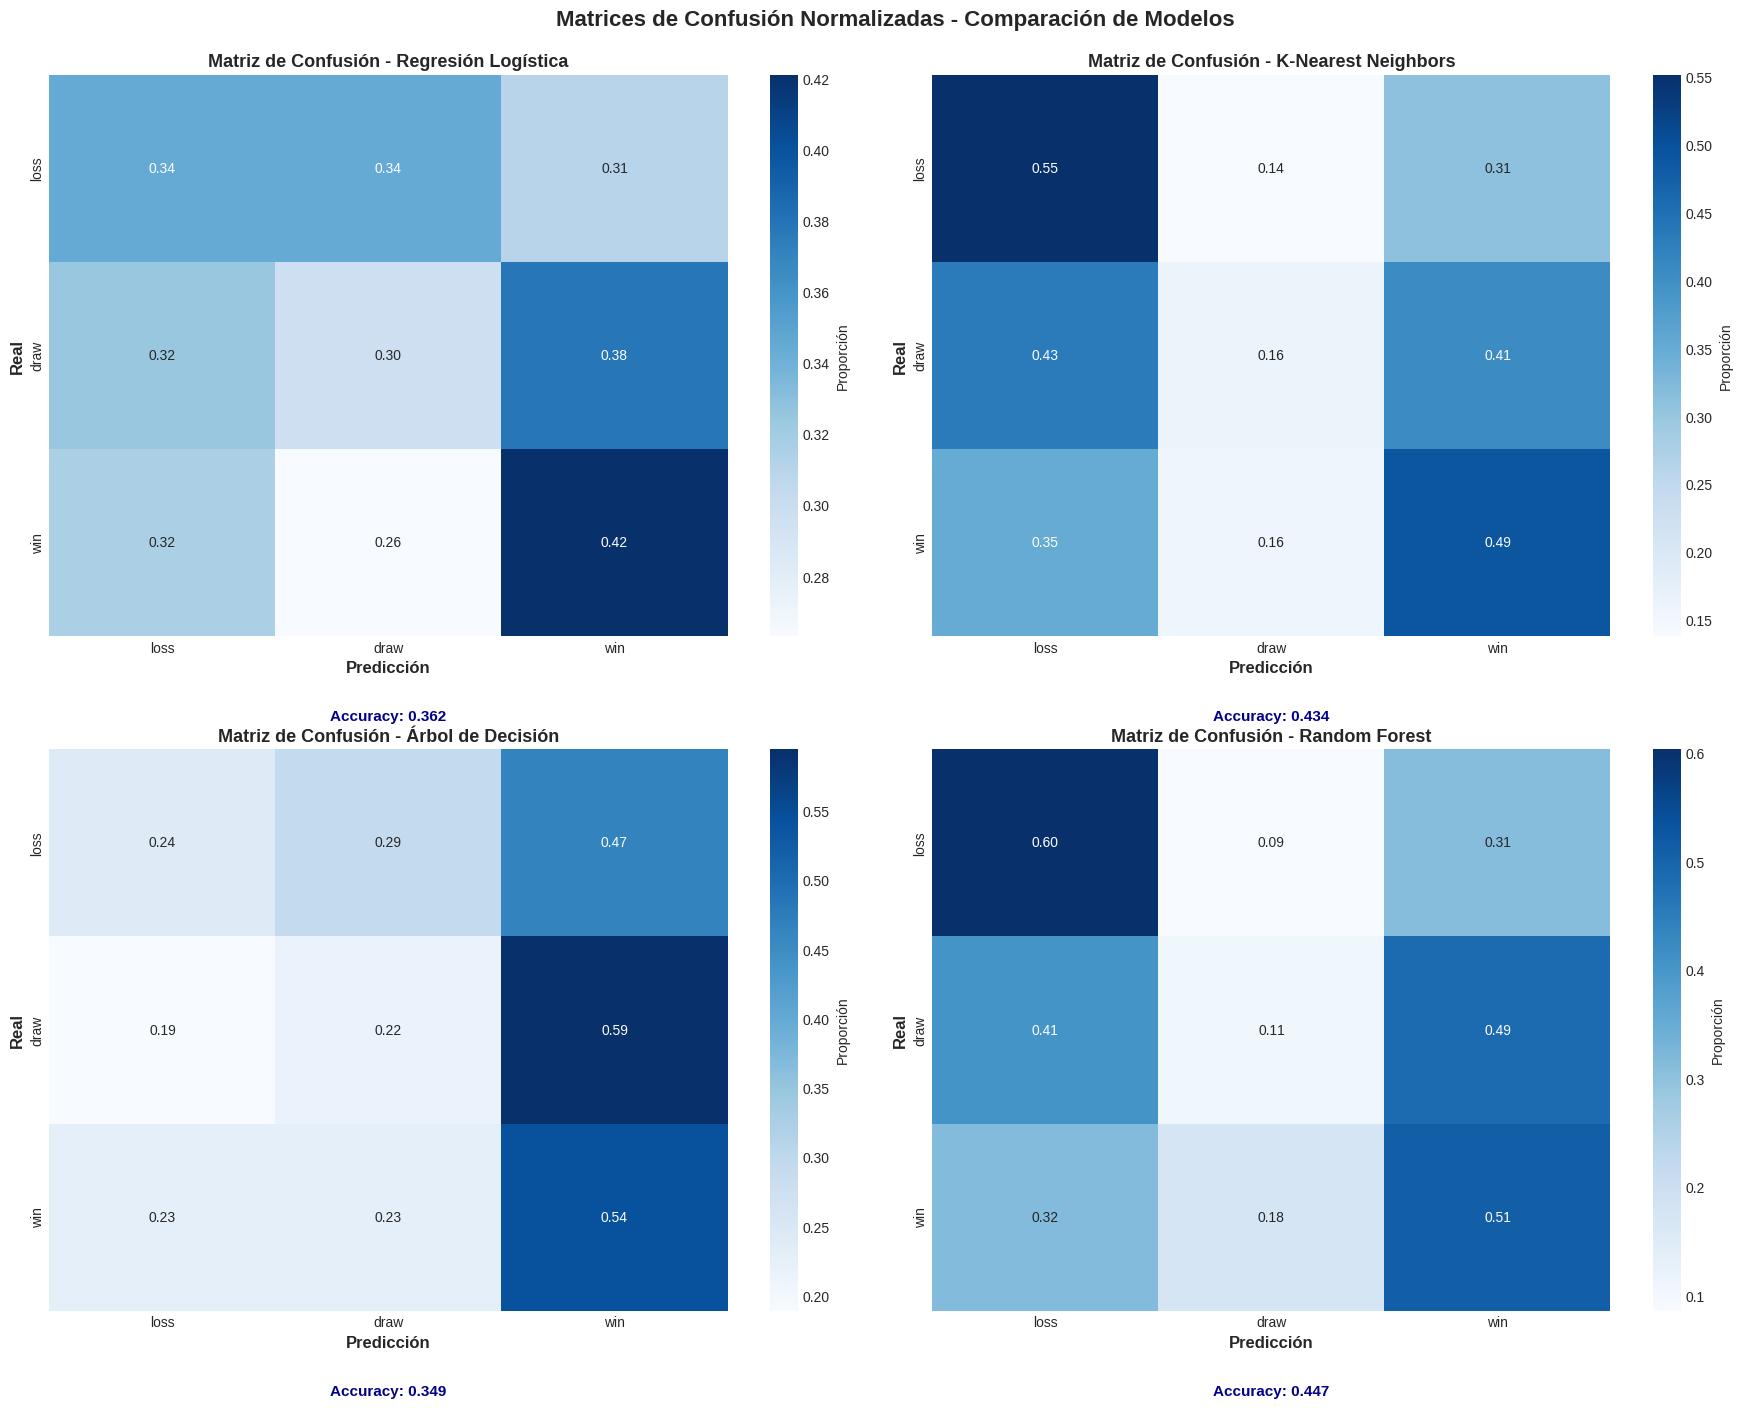

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, accuracy_score

# Orden fijo de clases (recomendado)
labels = ['loss', 'draw', 'win']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (model_name, model_info) in enumerate(models.items()):
    y_pred = model_info['predictions']

    # Matriz de confusión con orden fijo de clases
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    # Normalizar por filas (porcentaje por clase real)
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    # Visualizar
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[idx],
        cbar_kws={'label': 'Proporción'}
    )

    axes[idx].set_xlabel('Predicción', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Real', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'Matriz de Confusión - {model_name}', fontsize=13, fontweight='bold')

    # Accuracy debajo del gráfico
    acc = accuracy_score(y_test, y_pred)
    axes[idx].text(
        0.5, -0.15, f'Accuracy: {acc:.3f}',
        ha='center', transform=axes[idx].transAxes,
        fontsize=11, fontweight='bold', color='darkblue'
    )

plt.suptitle('Matrices de Confusión Normalizadas - Comparación de Modelos',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


CURVAS ROC

Las curvas ROC muestran el trade-off entre True Positive Rate (Recall) y False Positive Rate.

Interpretacion:

- **AUC** (Area Under Curve)= 1.0: Clasificador perfecto
- **AUC** =0.5: Clasificador aleatorio (línea diagonal)
- **AUC** > 0.8: Buen modelo

Para multiclase, usamos **One-vs-Rest (OvR)**: cada clase contra el esto

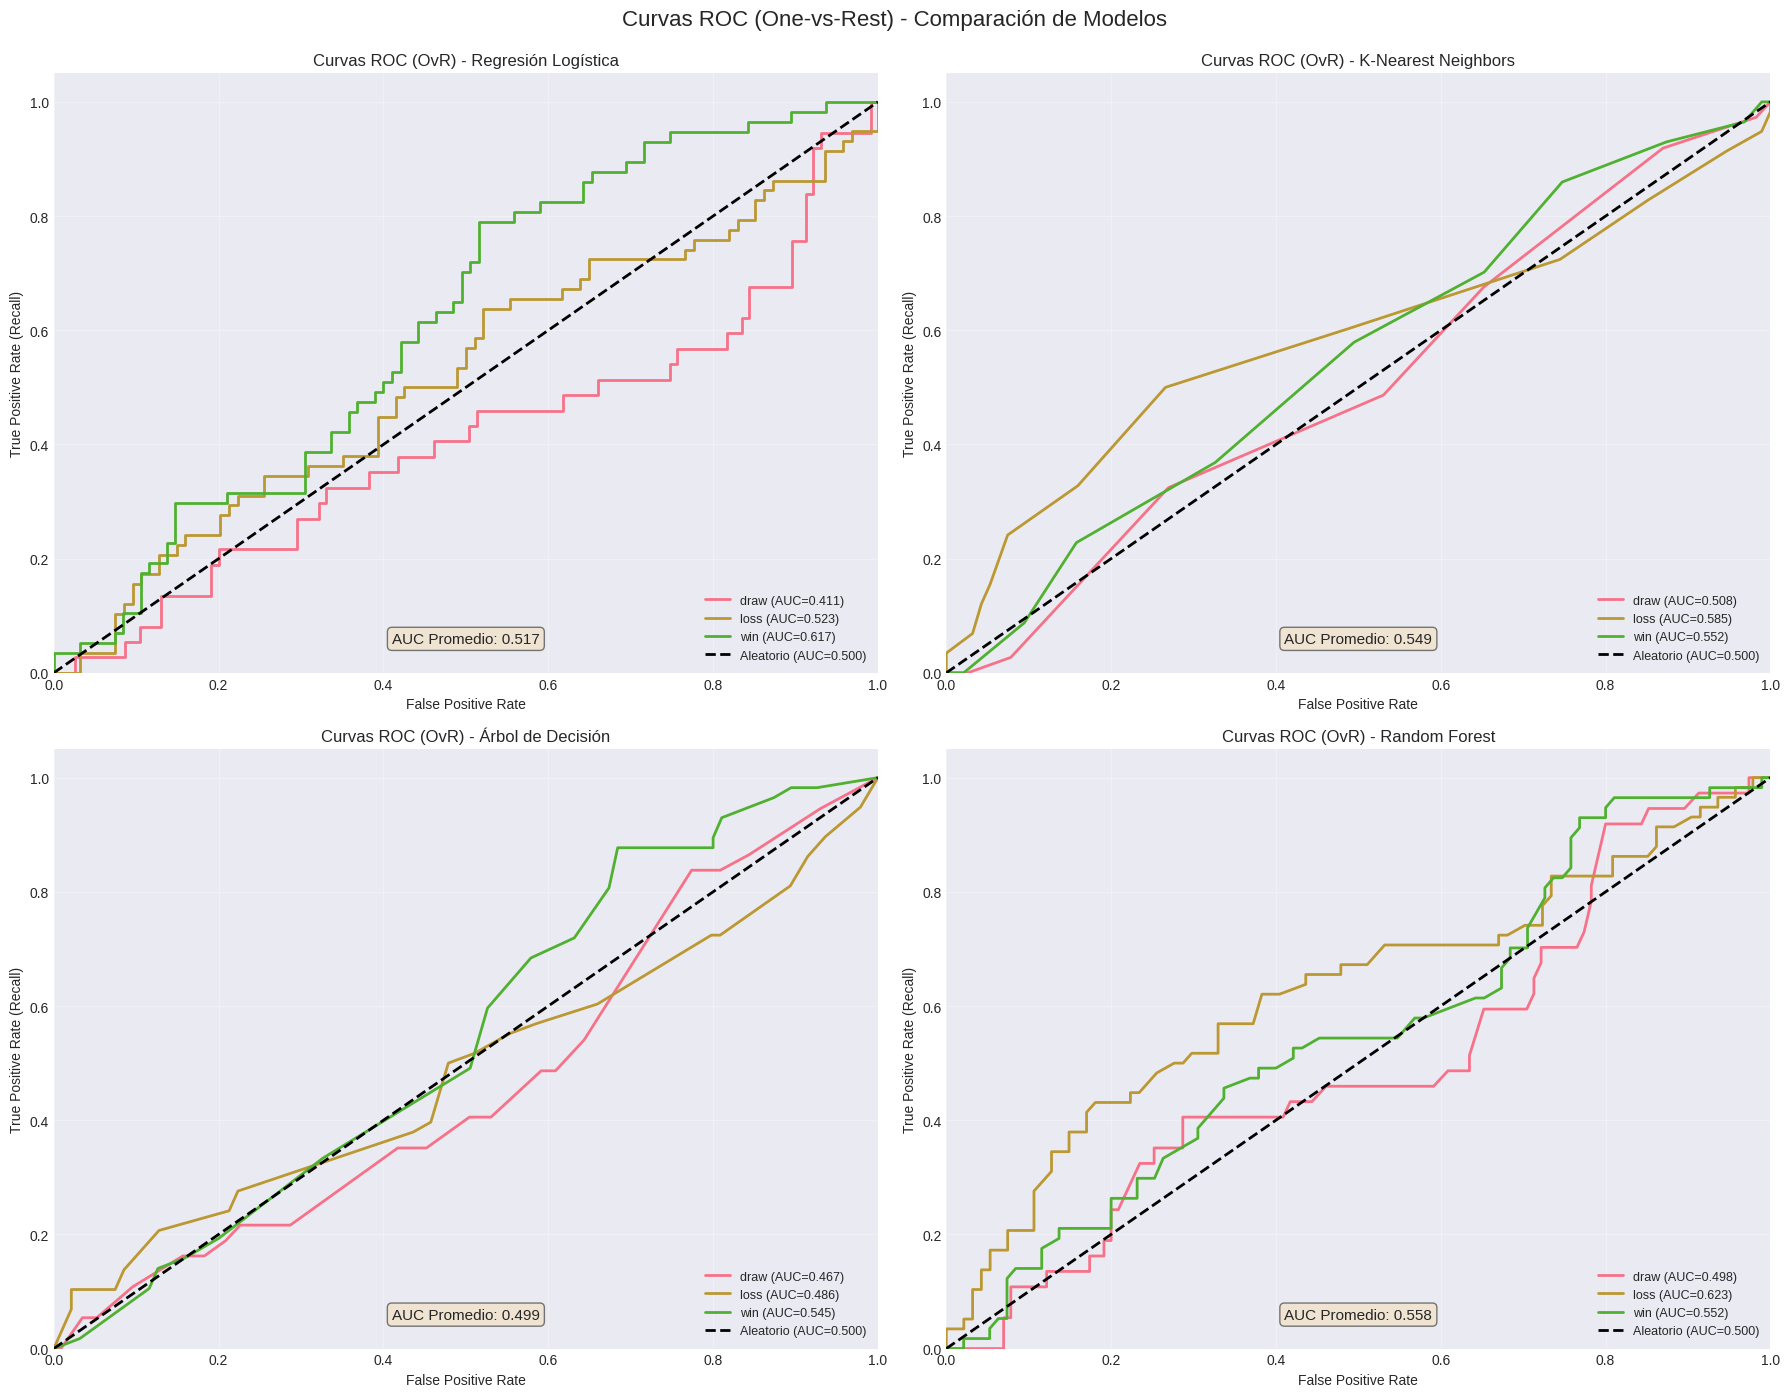

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (model_name, model_info) in enumerate(models.items()):
    model = model_info['model']
    ax = axes[idx]

    X_te = X_test_by_model[model_name]  # usa el test correcto

    # Obtener scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_te)
        # Si decision_function devuelve (n_samples,) en binario, habría que adaptar,
        # pero en multiclase suele devolver (n_samples, n_classes).
    else:
        ax.set_title(f'Curvas ROC - {model_name}\n(No disponible)')
        ax.axis('off')
        continue

    # ROC y AUC por clase
    roc_auc = {}
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f'{classes[i]} (AUC={roc_auc[i]:.3f})')

    # diagonal aleatorio
    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Aleatorio (AUC=0.500)')

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title(f'Curvas ROC (OvR) - {model_name}')
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)

    mean_auc = np.mean(list(roc_auc.values()))
    ax.text(0.5, 0.05, f'AUC Promedio: {mean_auc:.3f}',
            ha='center', transform=ax.transAxes,
            fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Curvas ROC (One-vs-Rest) - Comparación de Modelos', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()


OBSERVACIÓN

Las curvas ROC obtenidas presentan formas irregulares, lo cual es normal en problemas multiclase y con datasets de tamaño moderado. Estas curvas se generan a partir de distintos umbrales de decisión del modelo y relfejan su capacidad de discriminación entre clases. La proximidad de algunas curvas a la diagonal indica dificultad para separar ciertos resultados, especialmente en el caso de los empates, lo cual es coherente con la naturaleza incierta del fútbol.


# **CONCLUSIÓN**

Este proyecto ha aplicado la metodología CRISP-DM para desarrollar modelos de ML capaces de predecir el resultado de partidos de fúbtol a partir de variables previas al encuentro. Entre los algoritmos analizados, Random Forest ha mostrado el mejor rendimiento según el F1-Score ponderado, evidenciando su capacidad para identificar patrones relevantes en el rendimiento histórico y la forma reciente de los equipos.

Los resultados confirman que variables como el porcentaje de victorias, las victorias acumuladas o las métricas rolling tienen un papel clave en la predicción, aunque la naturaleza incierta del fúbtol limita la precisión alcanzable. Aun así, el modelo demuestra utilidad como herramienta de apoyo al análisis deportivo y abre las puerta a futuras mejoras mediante la incoroporación de nuevas variables y técnicas de modelado más avanzadas.

